In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as pit
import seaborn as sns


In [14]:
df = pd.read_csv("C:/Users/keert/Downloads/Real time Project/HR Employee Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


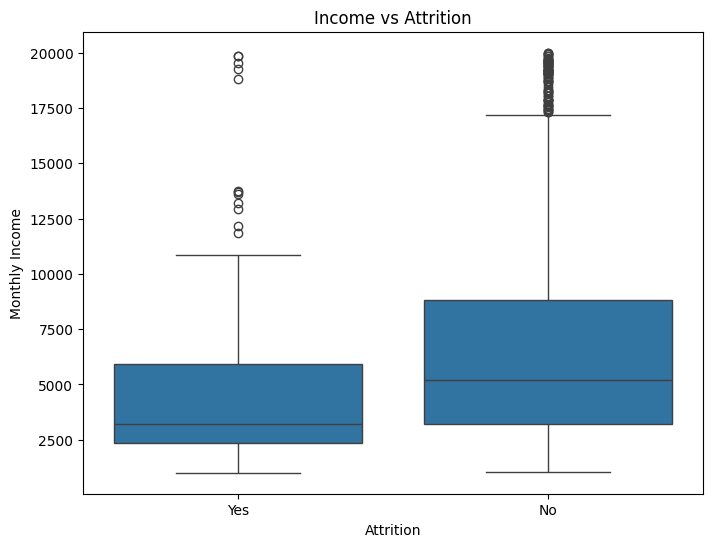

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

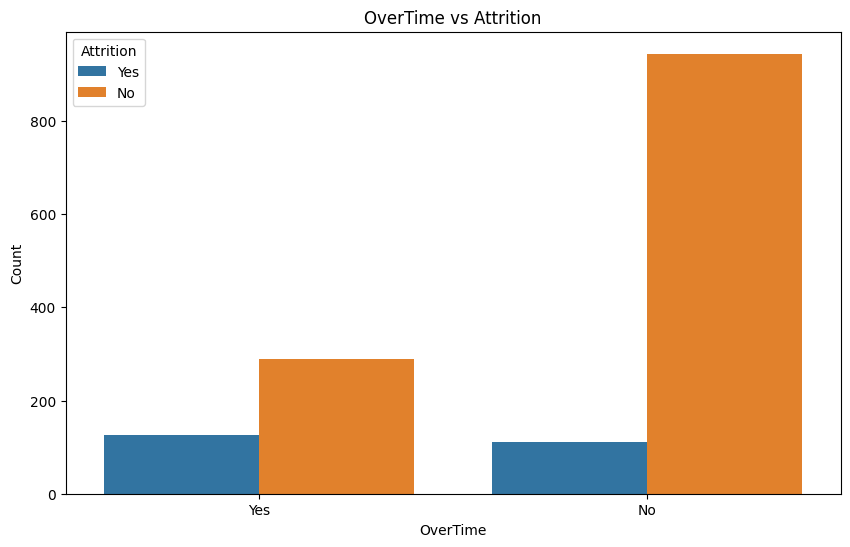

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [17]:
df.drop(columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], inplace=True)


encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    lb = LabelEncoder()
    df[col] = lb.fit_transform(df[col])
    encoder[col] = lb

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\keert\AppData\Local\Temp\ipykernel_29692\888146354.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


In [18]:
rf = RandomForestClassifier(random_state=42)


param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 50}


              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294

[[255   0]
 [ 35   4]]


Text(0, 0.5, 'Feature')

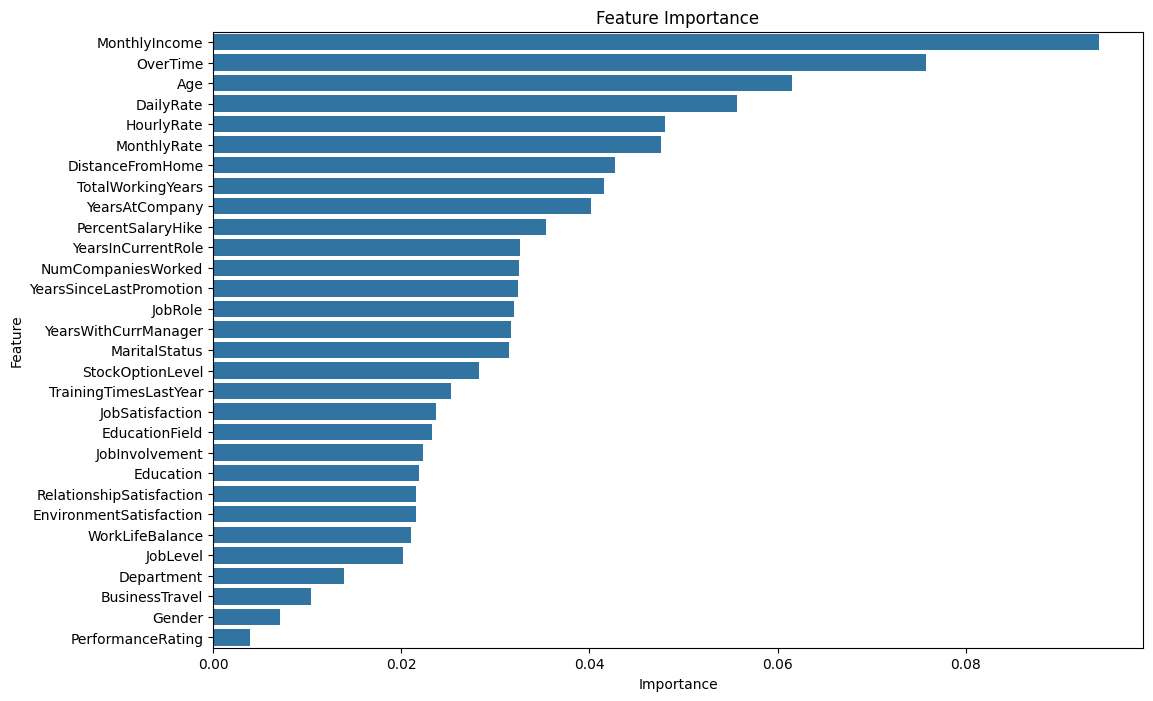

In [19]:
best_model = grid_search.best_estimator_
prediction = best_model.predict(X_test)

print(classification_report(y_test, prediction))
print(confusion_matrix(y_test, prediction))

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")


In [20]:
model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model.fit(X, y)

joblib.dump(model, "employee_attrition_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(X.columns.to_list(), "feature_columns.pkl")

['feature_columns.pkl']